# DevAgent 项目 - Day 4：构建 Multi-Agent 系统（LangGraph Supervisor + Worker 架构）

目标：
- 实现真正的 Multi-Agent 系统（Supervisor + 多个 Specialized Agents）
- 使用 LangGraph 构建状态图（StateGraph）
- 定义清晰的 Agent 角色分工（Researcher、Coder、Reviewer、Orchestrator）
- 实现动态任务路由和协作
- 为后续产品级打磨打好基础

作者：Sun | 10年开发经验 | Day 4
日期：2026-04-30

In [2]:
# ==================== 2. 配置环境 & LLM ====================

import os
from dotenv import load_dotenv
from pathlib import Path

load_dotenv(override=True)

from langchain_ollama import ChatOllama
from langchain_ollama import OllamaEmbeddings

# === 速度优化后的 LLM 配置（根据你昨天反馈优化）===
llm = ChatOllama(
    model="qwen2.5:14b",
    base_url="http://host.docker.internal:11434",   # 关键：访问主机
    temperature=0.2,
    num_ctx=8192,          # Agent 建议大一点的上下文
    num_gpu=999
)

# embeddings = OllamaEmbeddings(model="nomic-embed-text")   # 使用轻量 embedding 模型加速
embeddings = OllamaEmbeddings(model="qwen2.5:14b", base_url="http://host.docker.internal:11434")

print(f"✅ LLM 初始化完成 → {llm.model} | Context: {llm.num_ctx}")
print("✅ Embedding 模型已切换为轻量版（速度更快）")

✅ LLM 初始化完成 → qwen2.5:14b | Context: 8192
✅ Embedding 模型已切换为轻量版（速度更快）


In [ ]:
# ==================== 3. 加载 RAG Retriever（复用 Day 2） ====================

from langchain_chroma import Chroma

vectorstore = Chroma(
    persist_directory="/workspace/data/chroma_db",
    embedding_function=embeddings,
    collection_name="resume_knowledge"
)

retriever = vectorstore.as_retriever(search_kwargs={"k": 6})

print(f"✅ RAG Retriever 加载成功，共有 {vectorstore._collection.count()} 条向量")

In [5]:
# ==================== 4. 定义 Multi-Agent 专用 State ====================

from typing import TypedDict, Annotated, List, Sequence
from langchain_core.messages import BaseMessage
import operator

class AgentState(TypedDict):
    """Multi-Agent 系统核心状态"""
    messages: Annotated[Sequence[BaseMessage], operator.add]   # 累加消息历史
    next: str                                                  # Supervisor 决定下一个执行的 Agent
    task_plan: List[str]                                       # 任务分解计划
    resume_context: dict                                       # 简历提取的信息
    final_answer: str                                          # 最终输出

In [6]:
# ==================== 5. 定义多个 Specialized Agents （已修复 Prompt） ====================

from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import SystemMessage
from langchain.agents import create_agent

# Researcher Agent
researcher_system_prompt = """你是一位专业的研究助手。擅长从用户简历和互联网中查找信息。
你的任务是深入研究用户的技术背景、项目经验，并收集相关最新技术趋势。
回答要准确、结构化，并提供关键事实。"""

researcher_agent = create_agent(
    model=llm,
    tools=[retriever.as_tool(name="search_resume", description="在用户简历中搜索信息")],
    system_prompt=researcher_system_prompt   # 必须是 str 或 SystemMessage,
)

# Coder Agent
coder_system_prompt = """你是一位资深代码工程师（10年 Python + C# 经验）。
擅长生成高质量、可维护的代码，并进行代码审查。
生成代码时要包含详细注释，考虑生产级最佳实践（如错误处理、类型提示、可观测性）。"""

coder_agent = create_agent(
    model=llm,
    tools=[],
    system_prompt=coder_system_prompt
)

# Reviewer / Critic Agent
reviewer_system_prompt = """你是一位严格的代码审查者和质量把关者。
你的任务是仔细审查输出，指出潜在问题、逻辑错误、hallucination 和改进空间。
给出具体、建设性的改进建议，风格专业、严谨且客观。"""

reviewer_agent = create_agent(
    model=llm,
    tools=[],
    system_prompt=reviewer_system_prompt
)


print("✅ 三个 Agent 的 Prompt 已修复并创建完成")

✅ 三个 Agent 的 Prompt 已修复并创建完成


/tmp/ipykernel_22358/2983437243.py:14: LangChainBetaWarning: This API is in beta and may change in the future.
  tools=[retriever.as_tool(name="search_resume", description="在用户简历中搜索信息")],


In [7]:
# ==================== 6. 创建 Supervisor Agent（路由器） ====================

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from pydantic import BaseModel, Field

class RouteResponse(BaseModel):
    next: str = Field(..., description="下一个要执行的 Agent 名称")

supervisor_prompt = ChatPromptTemplate.from_template("""
你是一个 Multi-Agent 系统的 Supervisor（协调者）。
当前任务是帮助用户进行 AI 职业发展支持（简历优化、面试准备、技术研究等）。

已有对话历史：
{messages}

可用的 Agent 角色：
- Researcher：负责从简历和网络中收集信息
- Coder：负责生成和优化代码
- Reviewer：负责审查输出质量，提出改进意见
- FINISH：当任务已完成时选择此项

请决定下一步应该由哪个 Agent 执行。
如果任务已经可以给出最终答案，请回复 FINISH。

只返回以下格式（不要解释）：
{{"next": "Researcher"}} 或 {{"next": "Coder"}} 或 {{"next": "Reviewer"}} 或 {{"next": "FINISH"}}
""")

supervisor_chain = (
    supervisor_prompt 
    | llm.with_structured_output(RouteResponse)
)

print("✅ Supervisor Agent（路由器）创建完成")

✅ Supervisor Agent（路由器）创建完成


In [10]:
# ==================== 7. 构建 LangGraph Multi-Agent 工作流 ====================

from langgraph.graph import START, StateGraph, END
from langgraph.types import Send

# 定义节点函数
def researcher_node(state: AgentState):
    print("researcher_node")
    result = researcher_agent.invoke(state)
    return {"messages": result["messages"]}

def coder_node(state: AgentState):
    print("coder_node")
    result = coder_agent.invoke(state)
    return {"messages": result["messages"]}

def reviewer_node(state: AgentState):
    print("reviewer_node")
    result = reviewer_agent.invoke(state)
    return {"messages": result["messages"]}

def supervisor_node(state: AgentState):
    print("supervisor_node")
    response = supervisor_chain.invoke({"messages": state["messages"]})
    return {"next": response.next}

def reflection_node(state: AgentState):
    print("reflection_node")
    """简单 Reflection 节点"""
    if not state.get("messages"):
        print(f"no reflections")
        return {"reflections": ["无输出可反思"]}
    
    reflection = "反思：输出结构清晰，但可增加更多量化成果和具体项目案例以提升说服力。"
    print(f"🔀 reflection_node  ")
    
    return {
        "reflections": [reflection],
        "messages": state["messages"]
    }

def final_answer_node(state: AgentState):
    print("final_answer_node")
    """最终输出节点"""
    final_text = state["messages"][-1].content if state["messages"] else "无法生成最终答案"
    
    if state.get("reflections"):
        final_text += "\n\n【系统反思】\n" + "\n".join(state["reflections"])
    
    return {
        "final_answer": final_text,
        "messages": state["messages"]
    }

workflow = StateGraph(AgentState)

# 添加节点
workflow.add_node("Supervisor", supervisor_node)
workflow.add_node("Researcher", researcher_node)
workflow.add_node("Coder", coder_node)
workflow.add_node("Reviewer", reviewer_node)
workflow.add_node("Reflection", reflection_node)
workflow.add_node("Final_Answer", final_answer_node)

# 入口
workflow.add_edge(START, "Supervisor")

# Supervisor 路由
workflow.add_conditional_edges(
    "Supervisor",
    lambda s: s.get("next", "Final_Answer"),   # 添加默认值防止 KeyError
    {
        "Researcher": "Researcher",
        "Coder": "Coder",
        "Reviewer": "Reviewer",
        "Final_Answer": "Final_Answer"
    }
)

# 各 Agent 执行完 → Reflection → Supervisor
for node in ["Researcher", "Coder", "Reviewer"]:
    workflow.add_edge(node, "Reflection")

workflow.add_edge("Reflection", "Supervisor")

# Final_Answer 结束
workflow.add_edge("Final_Answer", END)

multi_agent = workflow.compile()

print("✅ Graph 构建完成（已优化路由和默认值）")

✅ Graph 构建完成（已优化路由和默认值）


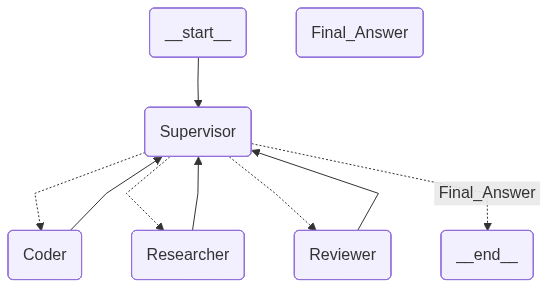

✅ Multi-Agent 工作流图可视化成功


In [17]:
# ==================== 8. 可视化 Multi-Agent Graph ====================
from IPython.display import Image as IPyImage, display

try:
    display(IPyImage(multi_agent.get_graph().draw_mermaid_png()))
    print("✅ Multi-Agent 工作流图可视化成功")
except Exception as e:
    print("可视化失败（可选）:", e)


In [11]:
# ==================== 9. 测试 Multi-Agent 系统 ====================

from langchain_core.messages import HumanMessage
from IPython.display import Markdown, display

config = {"configurable": {"thread_id": "multi_agent_test_001"}}

test_query = "请帮我准备一个针对 AI Engineer 岗位的简历优化方案，并给出技术面试准备建议"

print("🚀 开始 Multi-Agent 协作任务...\n")
print(f"用户任务: {test_query}\n")



result = multi_agent.invoke({
    "messages": [HumanMessage(content=test_query)],
    "task_plan": [],
    "resume_context": {}
}, config=config)

final_answer = result["messages"][-1].content

display(Markdown(f"### 🎯 Multi-Agent 最终输出\n\n{final_answer}"))

🚀 开始 Multi-Agent 协作任务...

用户任务: 请帮我准备一个针对 AI Engineer 岗位的简历优化方案，并给出技术面试准备建议

supervisor_node
researcher_node


KeyboardInterrupt: 